# Tutorial 2: Evaluating LLMs on MMLU

Welcome to the second tutorial in our AI Safety Evaluations course.

Benchmark evaluation is a core skill in applied ML, but the statistical side is often
treated as an afterthought — a single accuracy number gets reported, and model differences
are treated as real without checking whether they could arise from chance alone.
In this tutorial you will get hands-on experience running evaluations with the inspect_ai
library and applying basic statistical methods to interpret the results rigorously.

**What you'll learn:**

- Load and prepare a benchmark dataset
- Compute confidence intervals for accuracy
- Compare models statistically
- Perform power analysis to plan evaluation size

**By the end:** **You'll have a statistically rigorous evaluation pipeline that can tell you not just how accurate a model is, but whether observed differences between models are real.**

## 1. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm
from string import ascii_uppercase
from typing import Tuple, List

from inspect_ai import Task, task, eval
from inspect_ai.dataset import Sample, hf_dataset, FieldSpec
from inspect_ai.solver import multiple_choice
from inspect_ai.scorer import choice
from inspect_ai.log import EvalLog

%load_ext dotenv
%dotenv /root/.env

In [2]:
os.environ["OPENAI_API_KEY"] = os.environ["LITELLM_API_KEY"]
os.environ["OPENAI_BASE_URL"] = "https://srs-litellm.kontur.host/v1"

In [3]:
MODEL_A = "openai/code-pro"        # weaker / baseline model
MODEL_B = "openai/preview-code-pro"  # stronger / comparison model

## 2. Loading MMLU

`hf_dataset` is inspect_ai's loader for Hugging Face datasets. It downloads the data
and wraps each record in a `Sample` -- the standard container that flows through every
inspect_ai pipeline. A `Sample` carries the model input, the expected target, optional
answer choices, and arbitrary metadata you want to keep around.

MMLU stores the correct answer as an integer (0 = A, 1 = B, 2 = C, 3 = D).
The quickest way to load a dataset is with `FieldSpec`, which maps column names to
`Sample` fields. Let's try it first and see what we get.

In [4]:
dataset_raw = hf_dataset(
    path="cais/mmlu",
    name="all",
    split="test",
    sample_fields=FieldSpec(
        input="question",
        target="answer",           # raw MMLU answer is an integer index 0-3
        metadata=["choices", "subject"]
    ),
    cached=True
)

In [5]:
len(dataset_raw)

14042

In [6]:
sample = dataset_raw[0]
print("input   :", sample.input)
print("target  :", sample.target,  "  <- integer index, not a letter!")
print("choices :", sample.metadata.get("choices"))

input   : Find the degree for the given field extension Q(sqrt(2), sqrt(3), sqrt(18)) over Q.
target  : 1   <- integer index, not a letter!
choices : ['0', '4', '2', '6']


The `target` came out as an integer -- but inspect_ai's `multiple_choice()` solver
and `choice()` scorer expect it to be a letter (`"A"`, `"B"`, `"C"`, or `"D"`).
When the automatic mapping isn't enough, inspect_ai lets you pass a
**record-to-sample function** that receives the full raw record and returns a `Sample`
you construct yourself.

In [7]:
def record_to_sample(record: dict) -> Sample:
    """
    Convert a raw MMLU record to an inspect_ai Sample.

    MMLU stores the correct answer as an integer index (0=A, 1=B, 2=C, 3=D).
    We convert it to the corresponding uppercase letter so it matches the
    format expected by the choice() scorer.
    """
    answer_idx = int(record["answer"])
    return Sample(
        input=record["question"],
        choices=record["choices"],
        target=ascii_uppercase[answer_idx],   # 0->'A', 1->'B', ...
        metadata=dict(subject=record.get("subject"))
    )

In [8]:
dataset = hf_dataset(
    path="cais/mmlu",
    name="all",
    split="test",
    sample_fields=record_to_sample,
    cached=True
)

In [9]:
sample = dataset[0]
print("target  :", sample.target, " <- letter now")
print("choices :", sample.choices)

target  : B  <- letter now
choices : ['0', '4', '2', '6']


## Assignment 1: Create your working subset

All experiments in this notebook will run on a subject subset small enough to evaluate
quickly. `Dataset.filter()` takes a predicate over `Sample` objects; the `metadata`
field gives access to anything set in `record_to_sample` -- here, the MMLU subject tag.

We define `astronomy_subset` as a reference example. Pick any subject or subjects from the [MMLU subject list](https://huggingface.co/datasets/cais/mmlu#task-descriptions) with at least 50 questions so later analyses are statistically meaningful. Create MY_SUBSET and use it in all subsequent exercises.

In [10]:
MY_SUBSET = dataset.filter(lambda s: s.metadata.get("subject") == "abstract_algebra")

print(f"My subset: {len(MY_SUBSET)} questions")

My subset: 100 questions


## 3. Running an evaluation

Every inspect_ai evaluation is described by a `Task`, which bundles three things:

- **dataset** -- the questions
- **solver** -- the chain of steps that produces a model response;
  `multiple_choice()` formats the prompt with lettered options and parses the model's choice
- **scorer** -- the function that grades the response;
  `choice()` checks whether the selected letter matches the target

The `@task` decorator registers the function so inspect_ai can discover it by name
from the CLI or pass it directly to `eval()`.

In [11]:
@task
def mmlu_subset(subset):
    """Minimal MMLU task for any subject subset."""
    return Task(
        dataset=subset,
        solver=[multiple_choice()],
        scorer=choice()
    )

Calling `eval()` runs the task and returns a **list of `EvalLog` objects** -- one per
(task, model) pair. Everything you need is in this object; there is no need to read
log files from disk.

The two most useful attributes:
- `log.results.scores` -- list of scorer results, each with a `metrics` dict
  (`"accuracy"`, `"stderr"`, etc.)
- `log.samples` -- list of `EvalSample` objects with per-question inputs, outputs, and scores

In [12]:
logs: List[EvalLog] = eval(
    mmlu_subset(MY_SUBSET), # astronomy_subset,
    model=MODEL_A,
    epochs=2,
    limit=10        # evaluate only the first 10 questions
)

Output()

In [13]:
log = logs[0]      # one task -> one log
print("Status  :", log.status)
print("Model   :", log.eval.model)
print("Accuracy:", log.results.scores[0].metrics["accuracy"].value)

Status  : success
Model   : openai/code-pro
Accuracy: 0.85


## 4. From `EvalLog` to a DataFrame

## Assignment 2: Implement `log_to_df`

The aggregate accuracy in `log.results` is useful for a quick check, but for the
statistical analyses ahead we need a flat table: **one row per (question, epoch)**
with a numeric `score` column.

`log.samples` is a list of `EvalSample` objects. Each one has:
- `.id` -- question identifier
- `.epoch` -- which run this belongs to (relevant when `epochs > 1`)
- `.scores` -- a dict mapping scorer name to `Score`; the `Score.value` for `choice()` is
  `"C"` (correct) or `"I"` (incorrect)
- `.metadata` -- the metadata dict you set in `record_to_sample`

Implement `log_to_df` so that it converts an `EvalLog` into a DataFrame with columns
`id`, `epoch`, `score` (1/0), and `subject`. The smoke test below will verify the shape.

In [14]:
def log_to_df(log: EvalLog) -> pd.DataFrame:
    """
    Convert an EvalLog to a DataFrame with one row per (question, epoch).

    Columns:
        id      – question identifier
        epoch   – epoch index (0 if epochs=1)
        score   – 1 if correct, 0 otherwise
        subject – MMLU subject tag from metadata

    The choice() scorer stores the result as "C" (correct) or "I" (incorrect).
    """
    rows = []
    for sample in log.samples:
        # Extract score from the "choice" scorer
        score_value = sample.scores["choice"].value
        score = 1 if score_value == "C" else 0

        # Retrieve subject from metadata
        subject = sample.metadata.get("subject")

        rows.append({
            "id": sample.id,
            "epoch": sample.epoch,
            "score": score,
            "subject": subject
        })

    return pd.DataFrame(rows)

In [15]:
# =================================== TESTS ===================================
df_test = log_to_df(log)

assert set(df_test.columns) >= {"id", "epoch", "score", "subject"}
assert df_test["score"].isin([0, 1]).all()
#assert len(df_test) == 10

print(df_test.head())
print(f"\nAccuracy: {df_test['score'].mean():.1%}")

   id  epoch  score           subject
0   1      1      1  abstract_algebra
1   2      1      1  abstract_algebra
2   3      1      1  abstract_algebra
3   4      1      1  abstract_algebra
4   5      1      1  abstract_algebra

Accuracy: 85.0%


## 5. Confidence intervals


A single accuracy number carries uncertainty: the eval used a finite set of questions
sampled from a much larger space. The paper (ss2.1, ss3.1) shows how to quantify this
using the CLT standard error.


## Assignment 3: Implement `ci_accuracy_basic` and `ci_accuracy`

**`ci_accuracy_basic(scores, ci)`** -- the simple case where every question is answered
exactly once. `scores` is a plain numpy array of 0s and 1s. Use Eq. 1 from the paper.

**`ci_accuracy(df, ci)`** -- the general case that handles multiple runs per question
(`epochs > 1`). When K runs exist for a question, average their scores first, then
compute the SE across question-level averages. Pooling all K×n individual answers
would undercount variance -- answers to the same question across epochs are correlated.

In [16]:
def ci_accuracy_basic(scores: np.ndarray, ci: float = 0.95) -> tuple[float, float, float]:
    """
    CLT-based confidence interval for accuracy -- single run per question (K = 1).

    Parameters
    ----------
    scores : 1-D array of per-question binary scores (0 or 1)
    ci     : confidence level (default 0.95)

    Returns
    -------
    (lower_bound, mean_accuracy, upper_bound)
    """
    n = len(scores)
    if n == 0:
        raise ValueError("Empty scores array")

    p_hat = scores.mean()
    # Стандартная ошибка доли (standard error) по формуле для биномиального распределения: SE = sqrt(p*(1-p)/n)
    se = np.sqrt(p_hat * (1 - p_hat) / n)
    # Квантиль стандартного нормального распределения для заданного уровня доверия ci.
    # Для двустороннего интервала: z = Φ^{-1}(1 - α/2), где α = 1 - ci.
    z = norm.ppf(1 - (1 - ci) / 2)

    # Нижняя и верхняя границы доверительного интервала
    lower = p_hat - z * se
    upper = p_hat + z * se

    # Обрезаем границы до допустимого диапазона [0, 1], так как accuracy не может быть вне этого отрезка
    lower = max(0.0, lower)
    upper = min(1.0, upper)

    return lower, p_hat, upper

In [17]:
def ci_accuracy(df: pd.DataFrame, ci: float = 0.95) -> tuple[float, float, float]:
    """
    CLT-based confidence interval for accuracy, supporting multiple epochs (K >= 1).

    Parameters
    ----------
    df : DataFrame returned by log_to_df, with columns 'id', 'score', 'epoch'
    ci : confidence level (default 0.95)

    Returns
    -------
    (lower_bound, mean_accuracy, upper_bound)
    """
    # Группируем данные по идентификатору вопроса ('id') и для каждой группы вычисляем среднее значение 'score' по всем эпохам.
    # Получаем Series, из которого извлекаем массив значений (средние accuracy по каждому вопросу).
    question_means = df.groupby('id')['score'].mean().values
    n = len(question_means)
    if n == 0:
        raise ValueError("Empty DataFrame")

    # Далее, как ci_accuracy_basic

    p_hat = question_means.mean()
    # Стандартное отклонение средних по вопросам
    # (выборочное, с ddof=0 — как генеральное,
    # чтобы для K=1 результат совпадал с биномиальным подходом,
    # а для K>1 разница при большом n несущественна)
    s = question_means.std(ddof=0)
    # Стандартная ошибка среднего (SEM) — s / sqrt(n)
    se = s / np.sqrt(n)
    # Квантиль стандартного нормального распределения для заданного уровня доверия ci.
    # Для двустороннего интервала: z = Φ^{-1}(1 - α/2), где α = 1 - ci.
    z = norm.ppf(1 - (1 - ci) / 2)

    # Нижняя и верхняя границы доверительного интервала
    lower = p_hat - z * se
    upper = p_hat + z * se

    # Обрезаем границы до допустимого диапазона [0, 1], так как accuracy не может быть вне этого отрезка
    lower = max(0.0, lower)
    upper = min(1.0, upper)

    return lower, p_hat, upper

In [18]:
# =================================== TESTS ===================================
def _make_df(ids, scores, epochs=None):
    if epochs is None:
        epochs = [0] * len(ids)
    return pd.DataFrame({"id": ids, "score": scores, "epoch": epochs})

# ci_accuracy_basic
l, m, u = ci_accuracy_basic(np.ones(10))

assert l == 1.0 and u == 1.0, "perfect accuracy: CI should collapse to 1"

l, m, u = ci_accuracy_basic(np.zeros(10))

assert l == 0.0 and u == 0.0, "zero accuracy: CI should collapse to 0"

scores3 = np.array([1, 1, 0, 1, 0], dtype=float)
l, m, u = ci_accuracy_basic(scores3)

assert l < 0.6 < u, f"0.6 not in [{l:.3f}, {u:.3f}]"

np.random.seed(42)
s = np.random.binomial(1, 0.75, 200).astype(float)
l95, _, u95 = ci_accuracy_basic(s, 0.95)
l99, _, u99 = ci_accuracy_basic(s, 0.99)

assert (u99 - l99) > (u95 - l95), "99% CI must be wider than 95%"
assert np.isclose(l95, 0.6819421067148456, atol=10e-2)
assert np.isclose(u95, 0.8080578932851544, atol=10e-2)

# ci_accuracy (K=1 should match basic)
df3 = _make_df([1,2,3,4,5], scores3.tolist())
l_df, _, u_df = ci_accuracy(df3)
l_ar, _, u_ar = ci_accuracy_basic(scores3)

assert np.isclose(l_df, l_ar) and np.isclose(u_df, u_ar), "K=1 must match basic version"

# ci_accuracy (K=3 should give narrower CI on average)
np.random.seed(0)
rows_k1, rows_k3 = [], []
for q in range(30):
    p = np.random.uniform(0.3, 0.9)
    rows_k1.append({"id": q, "score": int(np.random.binomial(1, p)), "epoch": 0})
    for e in range(3):
        rows_k3.append({"id": q, "score": int(np.random.binomial(1, p)), "epoch": e})

l1, _, u1 = ci_accuracy(pd.DataFrame(rows_k1))
l3, _, u3 = ci_accuracy(pd.DataFrame(rows_k3))
print(f"K=1 width: {u1-l1:.3f}")
print(f"K=3 width: {u3-l3:.3f}  (narrower on average)")
print("\n✓ All tests passed!")

K=1 width: 0.337
K=3 width: 0.223  (narrower on average)

✓ All tests passed!


## 6. Visualising how CIs shrink

Two things make confidence intervals narrower: more questions (larger n) and more
runs per question (larger K). Your task is to visualise those effects.

## Assignment 4.1: Plot CI width vs number of epochs

In [19]:
logsA: List[EvalLog] = eval(
    mmlu_subset(MY_SUBSET),
    model=MODEL_A,
    epochs=10)

Output()

In [20]:
logsB: List[EvalLog] = eval(
    mmlu_subset(MY_SUBSET),
    model=MODEL_B,
    epochs=10)

Output()

In [21]:
dfA = log_to_df(logsA[0])
dfB = log_to_df(logsB[0])

print(len(dfA), len(dfB))

1000 1000


In [22]:
def plot_ci_vs_epochs(df):
    k_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
    
    accuracies = []
    ci_lowers = []
    ci_uppers = []
    
    for k in k_values:
        # Оставляем только первые k эпох для каждого вопроса (предполагается, что у каждого вопроса есть минимум k записей)
        df_k = df.groupby('id').head(k)
        
        # Вычисляем доверительный интервал для выбранного K
        lower, mean_acc, upper = ci_accuracy(df_k, ci=0.95)
        print(f'k={k}, range={upper-lower:0.3f}')
        
        accuracies.append(mean_acc)
        ci_lowers.append(lower)
        ci_uppers.append(upper)
    
    plt.figure(figsize=(8, 4))
    plt.fill_between(k_values, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
    plt.plot(k_values, accuracies, "o-", lw=2, label="Accuracy")
    plt.xlabel("Number of runs per question (K)")
    plt.ylabel("Accuracy")
    plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs k")
    plt.legend()
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

k=1, range=0.112
k=2, range=0.106
k=3, range=0.104
k=4, range=0.100
k=5, range=0.098
k=6, range=0.098
k=7, range=0.099
k=8, range=0.097
k=9, range=0.098
k=10, range=0.096


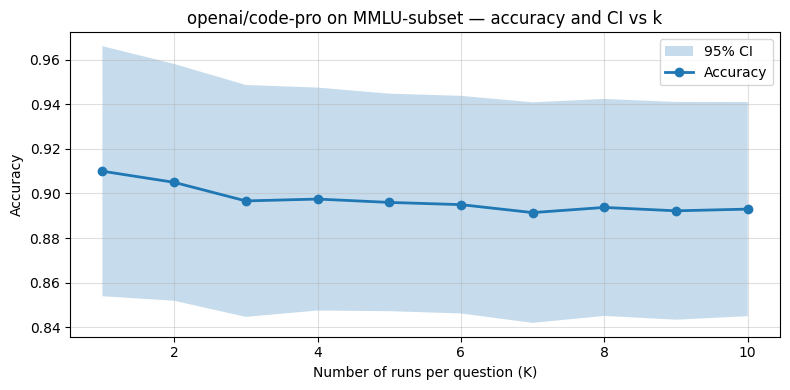

In [23]:
plot_ci_vs_epochs(dfA)

---
1. Look at how fast the band narrows.
   At what point does running another epoch stop being worth it?
2. Does more K change your estimate of the model's accuracy, or just your confidence in it?
3. What does this tell you about how to allocate your evaluation budget?

**Your answer:**

1. В моём случае сужение диапазона происходит до значения k=7. Дальнейшее увеличение кол-ва эпох нецелесообразно. При этом значительное сужение --- до k=4. С k=4 до k=7 сужение диапазона является незначительным. В общем случае, нужно фиксировать некоторый порог улучшения. Если улучшение доверительного интервала или уточнение accuracy не превосходит порога, то останавливаемя --- политика останова.
2. Увеличение k приводит к увеличению уверенности в оценке (за счёт сужения доверительных интервалов). Увеличение k не меняет истинного математического ожидания, но оценка (выборочное среднее) меняется --- увеличение k улучшает точность оценки (уменьшает её случайную ошибку) в силу закона больших чисел. 
3. Количество эпох имеет смысл повышать до тех пор, пока происходит существенное сужение доверительных интервалов. Дальнейшее увеличение k даст незначительное повышение точности.

k=1, range=0.077
k=2, range=0.077
k=3, range=0.077
k=4, range=0.077
k=5, range=0.077
k=6, range=0.077
k=7, range=0.077
k=8, range=0.077
k=9, range=0.077
k=10, range=0.077


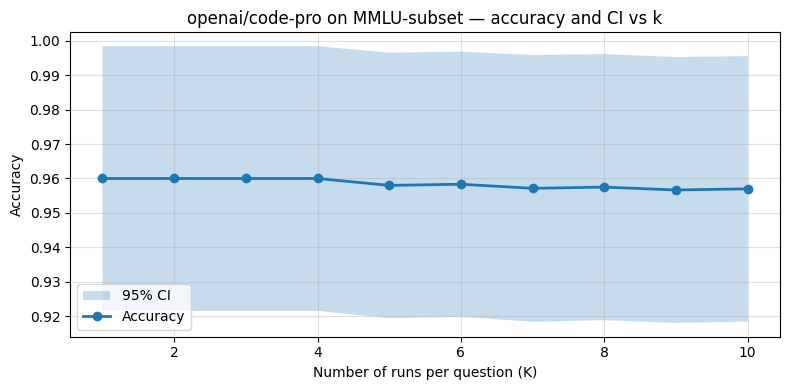

In [24]:
# более сильная модель

plot_ci_vs_epochs(dfB)

## Assignment 4.2: Compute and plot CI width vs n

For each sample size n in `range(10, len(question_ids)+1, 10)`, slice both DataFrames
to the first n question IDs, compute `ci_accuracy`, and record the CI width.
Then plot width vs n.

In [35]:
def plot_ci_vs_n(df):
    # уникальные ID вопросов, отсортированные
    question_ids = sorted(df['id'].unique())
    dataset_sizes = range(10, len(question_ids) + 1, 10)
    accuracies    = []
    ci_lowers     = []
    ci_uppers     = []
    
    for n in dataset_sizes:
        # берём первые n вопросов
        selected_ids = question_ids[:n]
        df_subset = df[df['id'].isin(selected_ids)]
        
        # вычисляем accuracy и доверительный интервал
        lower_ci, mean_acc, upper_ci = ci_accuracy(df_subset)
        accuracies.append(mean_acc)
        ci_lowers.append(lower_ci)
        ci_uppers.append(upper_ci)
    
    plt.figure(figsize=(8, 4))
    plt.fill_between(dataset_sizes, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
    plt.plot(dataset_sizes, accuracies, "o-", lw=2, label="Accuracy")
    plt.xlabel("Number of questions (n)")
    plt.ylabel("Accuracy")
    plt.title("MMLU-subset — accuracy and CI vs n")
    plt.legend()
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

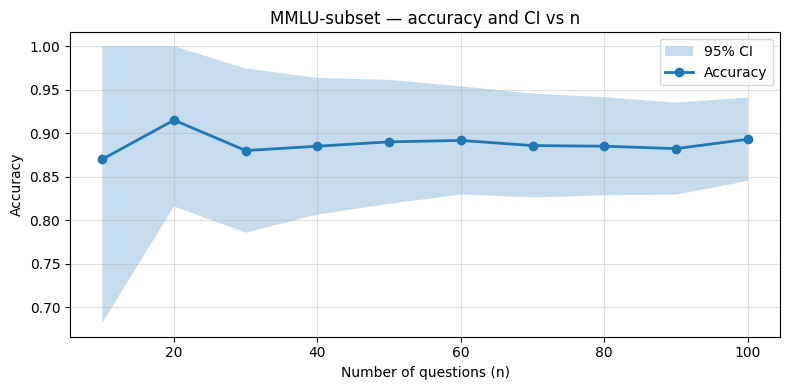

In [36]:
plot_ci_vs_n(dfA)

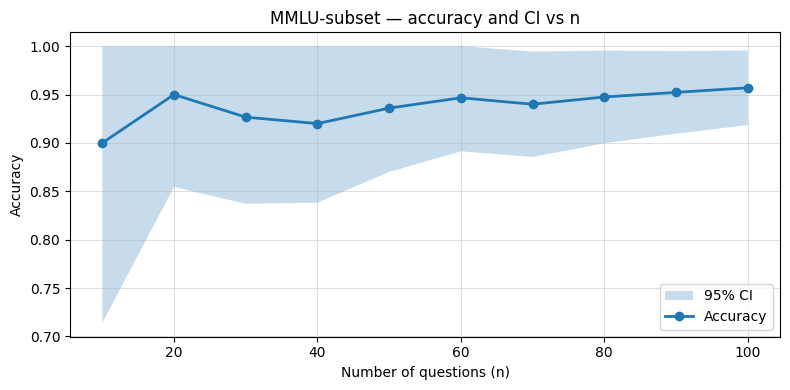

In [37]:
plot_ci_vs_n(dfB)

---
1. At what n does the accuracy line start to feel stable?
2. Compare that number to the size of `MY_SUBSET` — are you in the reliable region?
3. Compare this curve to the one in 4.1. What is the difference in what K and n actually buy you?

**Your answer:**

1. Для более слабой модели (MODEL_A) --- примерно, n = 50. Для более сильной модели (MODEL_B) --- кажется, что стабилизации нет, даже при n = 90 и 100 график возрастает.

2. Учитывая, что размер датасета равно 100, это достаточно, для MODEL_A, но недостаточно для MODEL_B.

3. Увеличение K делает оценку более устойчивой (меньше флуктуаций от прогона к прогону), но не меняет то, насколько выбранные вопросы отражают реальное распределение. Увеличение n делает оценку более репрезентативной (лучше приближает истинную accuracy на всём пространстве задач) и при этом тоже повышает точность, но уже за счёт большего объёма разных примеров.

## 7. Comparing two models

Reporting two accuracy numbers side by side doesn't tell you whether the gap is real
or just noise. The paper (§4.2) describes a **paired test**: because both models answer
the same questions, you can compute per-question score differences and test whether
their mean differs significantly from zero. This removes question-difficulty variance
and yields a lower standard error than treating the two runs as independent samples.

## Assignment 5: Compare two models

`run_and_get_scores` and `compare_models_paired` are provided. Complete
`significance_by_paired_ttest` and use it to compare the two models on `MY_SUBSET`.

Implement `significance_by_paired_ttest` and compare MODEL_A and MODEL_B.

In [38]:
def run_and_get_scores(model_name: str, dataset, epochs: int = 1) -> np.ndarray:
    """Run eval and return mean-per-question scores, sorted by question id."""
    print(f"  Running {model_name} ...")
    run_logs = eval(mmlu_subset(dataset), model=model_name, epochs=epochs)
    df = log_to_df(run_logs[0])
    return df.groupby("id")["score"].mean().sort_index().values

In [39]:
from scipy.stats import ttest_rel

def significance_by_paired_ttest(
    scores1: np.ndarray,
    scores2: np.ndarray,
    alpha: float = 0.05,
    two_tailed: bool = True,
) -> Tuple[float, float, bool]:
    """
    Paired t-test between two sets of per-question scores.

    Returns (p_value, mean_difference scores1 - scores2, is_significant).
    """
    assert len(scores1) == len(scores2), "arrays must cover the same questions"
    
    alternative = "two-sided" if two_tailed else "greater"
    
    # вычисляем парный t-критерий
    t_stat, p_value = ttest_rel(scores1, scores2)
    mean_diff = np.mean(scores1 - scores2)
    
    # корректировка для одностороннего теста (например, проверка, что модель A лучше B)
    if not two_tailed:
        if alternative == "greater":
            # H1: mean(scores1) > mean(scores2)
            p_value = p_value / 2 if t_stat > 0 else 1 - p_value / 2
        else:  # alternative == "less"
            # H1: mean(scores1) < mean(scores2)
            p_value = p_value / 2 if t_stat < 0 else 1 - p_value / 2
    
    return p_value, mean_diff, p_value < alpha

In [41]:
# =================================== TESTS ===================================
p, d, sig = significance_by_paired_ttest(np.array([1,2,3]), np.array([1,2,3]))

assert np.isclose(d, 0.0) and not sig

p, d, sig = significance_by_paired_ttest(
    np.array([1,1,1,1,1]), np.array([0,0,0,0,0]), two_tailed=False
)

assert sig and d > 0

print("All tests passed!")

All tests passed!


/usr/local/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [40]:
def compare_models_paired(
    model_a: str,
    model_b: str,
    dataset,
    alpha: float = 0.05,
    two_tailed: bool = True,
    epochs_a: int = 1,
    epochs_b: int = 1,
) -> Tuple[float, float, bool]:
    """
    Evaluate both models on the same dataset and run a paired t-test.

    Returns (p_value, mean_difference A - B, is_significant).
    """
    scores_a = run_and_get_scores(model_a, dataset, epochs=epochs_a)
    scores_b = run_and_get_scores(model_b, dataset, epochs=epochs_b)
    return significance_by_paired_ttest(scores_a, scores_b, alpha, two_tailed)

In [43]:
p_value, mean_diff, significant = compare_models_paired(
    MODEL_A, MODEL_B, MY_SUBSET, alpha=0.05, two_tailed=True, epochs_a=4, epochs_b=4
)

print(f"p-value: {p_value:.4f}")
print(f"Mean difference (A - B): {mean_diff:.4f}")
print(f"Statistically significant (p < 0.05): {significant}")

Output()

  Running openai/code-pro ...


Output()

  Running openai/preview-code-pro ...


p-value: 0.0019
Mean difference (A - B): -0.0625
Statistically significant (p < 0.05): True


- p-value: 0.0019
- Mean difference (A - B): -0.0625
- Statistically significant (p < 0.05): True

Различие в качестве моделей не объясняется случайными колебаниями — модель B действительно лучше модели A на данном наборе вопросов

---
1. Write down the p-value and the mean difference you got.
2. Is the gap significant? Is it large enough to matter in practice?
3. What would change your conclusion: more questions, a different subject, or a different model pair?

**Your answer:**

1. p-value = 0.0019, mean difference (A - B) = -0.0625
2. Разница статистически значима. Разница (89.7% vs 96%) является значительной, на практике это может означать в два раза меньше ошибок.
3. Больше вопросов --- нет. Другая тема --- да, другая пора моделей --- тоже, да.

## 8. Interval estimation of the accuracy difference

In Assignment 5 you got a yes/no significance decision. Here you will estimate the size of the gap and its uncertainty: a confidence interval on the difference gives both pieces of information at once.

## Assignment 6: Estimate the accuracy gap

Implement `ci_accuracy_for_difference` to compute a 95% CI on the per-question score differences.

Compute and report the confidence interval on MODEL_A − MODEL_B.


In [45]:
from scipy.stats import t

def ci_accuracy_for_difference(
    scores1: np.ndarray,
    scores2: np.ndarray,
    alpha: float = 0.05,
) -> Tuple[float, float, float]:
    """
    Возвращает (mean_diff, lower_ci, upper_ci) для разницы scores1 - scores2.
    Интервал построен для среднего по вопросам.
    """
    diffs = scores1 - scores2
    n = len(diffs)
    mean_diff = np.mean(diffs)
    std_err = np.std(diffs, ddof=1) / np.sqrt(n)
    t_crit = t.ppf(1 - alpha / 2, df=n - 1)
    margin = t_crit * std_err
    lower = mean_diff - margin
    upper = mean_diff + margin
    return mean_diff, lower, upper

In [51]:
scores_a = dfA.groupby("id")["score"].mean().sort_index().values
scores_b = dfB.groupby("id")["score"].mean().sort_index().values

# Вычисляем доверительный интервал для разницы A - B
mean_diff, lower_ci, upper_ci = ci_accuracy_for_difference(scores_a, scores_b)

print(f"Разница (A - B): {mean_diff:.4f}")
print(f"95% доверительный интервал: [{lower_ci:.4f}, {upper_ci:.4f}]")

Разница (A - B): -0.0640
95% доверительный интервал: [-0.0991, -0.0289]


---
1. Write down the interval. Does it contain zero?
2. How does this relate to the significance test in Assignment 5 — do they tell the same story?
3. Which result is more informative — the p-value or the interval? Why?

**Your answer:**

1. Интервал [-0.0991, -0.0289] не содержит ноль, т.е. с вероятностью 95% (дефолтное значение) модель B статистически значимо превосходит модель A
2. Да, тот же вывод.
3. Доверительный интервал. Он позволяет оценить размер эффетка (насколько далеки границы интервала от ноля) и меру неопределённости (ширина интервала)

## 9. Power analysis

Before running an expensive evaluation, it is worth asking: how many questions do we
need to detect a meaningful difference with adequate statistical power?
The paper (§5) derives the minimum detectable effect as a function of sample size n,
question-level variance ω², and within-model variance σ².

## Assignment 7: 'Estimate variance components'

Implement `estimate_variance_components` and report the MDE for `MY_SUBSET` at α = 0.05, power = 80%.

In [64]:
def estimate_variance_components(
    logs_a: List[EvalLog],
    logs_b: List[EvalLog],
) -> dict:
    """
    Estimate omega2, sigma2_a, sigma2_b from two EvalLog objects (see ss5 of the paper).

    Both logs must cover the same set of questions. Use epochs >= 2 so that
    within-question variance can be estimated.

    Returns dict with keys 'omega2', 'sigma2_a', 'sigma2_b'.
    """
    # convert list of EvalLog to DataFrame with columns id, epoch, score
    def logs_to_df(logs):
        dfs = []
        for epoch_idx, log in enumerate(logs):
            df = log_to_df(log)
            df['epoch'] = epoch_idx
            dfs.append(df)
        return pd.concat(dfs, ignore_index=True)
    
    df_a = logs_to_df(logs_a)
    df_b = logs_to_df(logs_b)
    
    # Модель A
    grouped_a = df_a.groupby('id')['score']
    means_a = grouped_a.mean()
    vars_a  = grouped_a.var(ddof=1)
    sigma2_a = vars_a.mean()
    
    # Модель B
    grouped_b = df_b.groupby('id')['score']
    means_b = grouped_b.mean()
    vars_b  = grouped_b.var(ddof=1)
    sigma2_b = vars_b.mean()
    
    # Объединяем средние по вопросам (берём только общие id)
    common_ids = means_a.index.intersection(means_b.index)
    means_a = means_a[common_ids]
    means_b = means_b[common_ids]
    
    # Разности средних по вопросам
    diffs = means_a - means_b
    var_d = diffs.var(ddof=1)       # выборочная дисперсия разностей
    
    K_a = len(logs_a)
    K_b = len(logs_b)
    # Оценка дисперсии истинных различий (omega^2)
    omega2 = var_d - (sigma2_a / K_a + sigma2_b / K_b)
    omega2 = max(0.0, omega2)       # неотрицательная
    
    return {
        "omega2": omega2,
        "sigma2_a": sigma2_a,
        "sigma2_b": sigma2_b,
    }

In [65]:
def minimum_detectable_effect(
    n: int,
    omega2: float,
    sigma2_a: float = 0.0,
    sigma2_b: float = 0.0,
    ka: int = 1,
    kb: int = 1,
    alpha: float = 0.05,
    power: float = 0.80,
) -> float:
    """MDE for a paired model comparison (Eq. 10 in the paper)."""
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta  = stats.norm.ppf(power)
    return float((z_alpha + z_beta) * np.sqrt(
        (omega2 + sigma2_a / ka + sigma2_b / kb) / n
    ))

In [58]:
print("Running pilot evals ...")
logs_a = eval(mmlu_subset(MY_SUBSET), model=MODEL_A, epochs=2, limit=15)
logs_b = eval(mmlu_subset(MY_SUBSET), model=MODEL_B, epochs=2, limit=15)

Output()

Running pilot evals ...


Output()

In [66]:
params = estimate_variance_components(logs_a, logs_b)
print(f"omega2  = {params['omega2']:.4f}")    # дисперсия истинных различий между моделями по вопросам
print(f"sigma2_A = {params['sigma2_a']:.4f}") # внутривпросная дисперисия модели A
print(f"sigma2_B = {params['sigma2_b']:.4f}") # внутривпросная дисперисия модели B

omega2  = 0.0000
sigma2_A = 0.0667
sigma2_B = 0.0000


In [67]:
mde = minimum_detectable_effect(n=len(MY_SUBSET), **params)
print(f"\nWith n={len(MY_SUBSET)} questions -> MDE = {mde:.1%}")
print("(smallest gap detectable at 80% power, alpha=0.05)")


With n=100 questions -> MDE = 7.2%
(smallest gap detectable at 80% power, alpha=0.05)


---
1. What MDE did you get for `MY_SUBSET`? Is that gap practically meaningful?
2. If the MDE is larger than the gap you observed in Assignment 5,
   what does that say about your earlier result?

**Your answer:**

Получили MDE = 7.2%, т.е. с заданными параметрами минимальная разница между моделями, которую можно статистически значимо обнаружить, это 7.2%.
Ранее была получена разница в пользу модели B --- 6.25%.
Это немного меньше, чем MDE. Но тест её обнаружил (было большая мощность, например).

Если хочеться обнаружить разницу в 5%, то надо либо:
- увеличить количество вопросов N (формула MDE ~ 1/√n, так что для уменьшения MDE в 1.44 раза нужно удвоить N)
- увеличить число прогонов k_A, k_B (особенно для нестабильной модели A, где sigma2_A = 0.0667

## Assignment 8: Implement `required_sample_size`

`minimum_detectable_effect` computes delta given n. Implement its inverse:
given a target delta, return the minimum n needed. Use the sample-size formula
from ss5 of the paper (Eq. 9). Verify it passes the round-trip check,
then use it to compute how many questions you would need to detect a 5% and a 10%
accuracy gap on `MY_SUBSET`.

In [70]:
def required_sample_size(
    delta: float,
    omega2: float,
    sigma2_a: float = 0.0,
    sigma2_b: float = 0.0,
    ka: int = 1,
    kb: int = 1,
    alpha: float = 0.05,
    power: float = 0.80,
) -> int:
    """Minimum number of questions needed to detect `delta` at the given power."""
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta  = stats.norm.ppf(power)
    var_total = omega2 + sigma2_a / ka + sigma2_b / kb
    n_float = ((z_alpha + z_beta) ** 2 * var_total) / (delta ** 2)
    return int(np.ceil(n_float))

In [74]:
# =================================== TESTS ===================================
n_needed = required_sample_size(delta=0.05, **params)
print(f"Questions needed to detect delta=5%: {n_needed}")

mde_check = minimum_detectable_effect(n=n_needed, **params)

assert abs(mde_check - 0.05) < 0.005, f"Round-trip failed: MDE={mde_check:.3f}"

print("Round-trip check passed!")

Questions needed to detect delta=5%: 210
Round-trip check passed!


In [73]:
# Сколько вопросов нужно для обнаружения разницы 5% и 10% на MY_SUBSET?
# Предположим, что будущие эксперименты будут проводиться с одним прогоном на вопрос (k_A = k_B = 1).

# Для 5% (абсолютных)
n_5 = required_sample_size(delta=0.05, **params, ka=1, kb=1)
print(f"Обнаружение разницы 5% необходимо {n_5} вопросов")

# Для 10%
n_10 = required_sample_size(delta=0.10, **params, ka=1, kb=1)
print(f"Обнаружение разницы 10% необходимо {n_10} вопросов")

Обнаружение разницы 5% необходимо 210 вопросов
Обнаружение разницы 10% необходимо 53 вопросов


In [75]:
# Сколько вопросов нужно для обнаружения разницы 5% и 10% на MY_SUBSET?
# Предположим, что будущие эксперименты будут проводиться с 4 прогонами на вопрос (k_A = k_B = 4).

# Для 5% (абсолютных)
n_5 = required_sample_size(delta=0.05, **params, ka=4, kb=4)
print(f"Обнаружение разницы 5% необходимо {n_5} вопросов")

# Для 10%
n_10 = required_sample_size(delta=0.10, **params, ka=4, kb=4)
print(f"Обнаружение разницы 10% необходимо {n_10} вопросов")

Обнаружение разницы 5% необходимо 53 вопросов
Обнаружение разницы 10% необходимо 14 вопросов


---
1. How many questions do you need to detect a 5% gap? A 10% gap?
2. Does `MY_SUBSET` have enough questions to be a useful benchmark for comparing these two models?

**Your answer:**

Для 5% --- 210, для 10% --- 53. Но если больше прогонов (epochs), то потребуется меньше.
И размера датасета будет достаточно (в нём 100 вопросов).

## Assignment 9: Compare a model with itself: baseline vs chain-of-thought

The `multiple_choice()` solver we have used so far prompts the model to answer
directly. inspect_ai also provides a `chain_of_thought` that asks the model
to reason step by step before giving its final answer.

Using the paired comparison infrastructure from Section 7, evaluate the same model
twice on the same subset — once with the default solver and once with
`chain_of_thought` — and test whether the difference in accuracy is statistically
significant. Does reasoning help? Is the effect consistent across subjects?

In [136]:
from inspect_ai.solver import chain_of_thought, chain

In [137]:
def log_to_df_2(log: EvalLog) -> pd.DataFrame:
    rows = []
    for sample in log.samples:
        score_value = sample.scores["choice"].value
        score = 1 if score_value == "C" else 0
        subject = sample.metadata.get("subject")
        rows.append({
            "id": sample.id,
            "epoch": sample.epoch,
            "score": score,
            "subject": subject
        })

    return pd.DataFrame(rows)

In [138]:
task = Task(dataset=MY_SUBSET, solver=multiple_choice(), scorer=choice())
run_logs = eval(task, model=MODEL_A, epochs=2)
df = log_to_df_2(run_logs[0])
scores_default = df.groupby("id")["score"].mean().sort_index().values

Output()

In [139]:
task = Task(dataset=MY_SUBSET, solver=chain(chain_of_thought(), multiple_choice()), scorer=choice() )
run_logs = eval(task, model=MODEL_A, epochs=2)
df = log_to_df_2(run_logs[0])
scores_cot = df.groupby("id")["score"].mean().sort_index().values

Output()

In [140]:
p_val, mean_diff, is_sig = significance_by_paired_ttest(
    scores_cot, scores_default, alpha=0.05, two_tailed=True
)

print(f"p-value: {p_val:.4f}")
print(f"Mean difference (CoT - Default): {mean_diff:.4f}")
print(f"Statistically significant (p < 0.05): {is_sig}")

p-value: 0.1273
Mean difference (CoT - Default): 0.0350
Statistically significant (p < 0.05): False


---
1. Does chain-of-thought help? By how much, and is it significant?
2. Does the result surprise you? What might explain it?
3. Would you expect the same pattern on a different subject?

**Your answer:**

1. Среднее значение accuracy при использовании Chain-of-Thought выше на 0.035, но эта разница не достигает уровня статистической значимости (p = 0.127 > 0.05). Т.е. эффект есть, но он нестабильный. С вероятностью около 87% (1 - p) наблюдаемое улучшение не является случайным "шумом", но обычно используют порог 95% (p < 0.05).

2. Результат попадает в моё ожидание (будет улучшение, но не на порядок). Задачи достаточно сложные для такой не слишком большой модели.

3. Польза от Chain-of-Thought зависит от решаемой задачи. В моём случае это абстрактная алгебра и рассуждения должны помогать. Но если вопрос на факты, то рассуждения не помогут.

## Bonus assignment: Clustered Standard Errors

Some benchmarks contain groups of related questions — for example, several questions
about the same passage in reading comprehension tasks like DROP or RACE. In such cases
the standard CLT confidence interval is anti-conservative: questions within a group are
correlated, so the effective sample size is smaller than n. Miller (2024) addresses this
with clustered standard errors (§2.2).

Using a reading comprehension benchmark of your choice, implement the clustered
confidence interval (Eq. 4 from the paper) and compare it against the naive CLT interval.
How much wider is the clustered interval? Does the difference depend on the benchmark?
Then compare two models on the same benchmark using the clustered paired standard error
(Eq. 8) — does the conclusion about which model is better change compared to the
naive paired test?

In [ ]:
# YOUR CODE HERE